# Code to get SNe Fisher matrix + Biases

## Observable: Distance modulus $\mu$ for multiple redshift bins from SNe (LSST or DES).

In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
#load modules
import numpy as np, sys, os
sys.path.append('modules/')
import sne_cmb_fisher_tools, misc
from astropy import constants as const
from astropy import units as u
from astropy import coordinates as coord
from astropy.cosmology import FlatLambdaCDM
from pylab import *

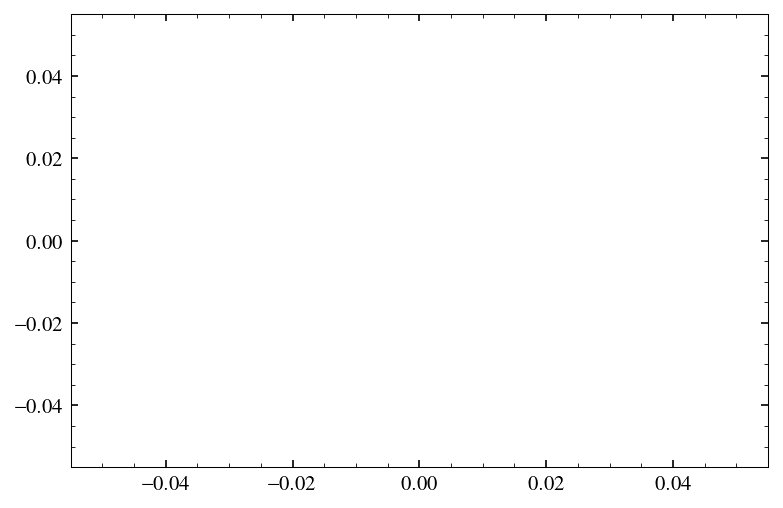

In [5]:
rcParams['figure.dpi'] = 150
rcParams['figure.facecolor'] = 'white'
plot(); show()

In [11]:
#some variables
#which_sne_data = 'lsst_binned'
which_sne_data = 'lsst_unbinned'
#which_sne_data = 'des'
#which_sne_data = 'test'
unbinned_sne_sim_no = 1
add_stat_error = 1

transform_fisher = False

#get sne details
print('\nget sne details')
sne_details_dic = sne_cmb_fisher_tools.get_sne_details(which_sne_data, add_stat_error, unbinned_sne_sim_no = unbinned_sne_sim_no, obtain_covs = False)
sne_zarr = sne_details_dic['sne_zarr']
sne_muarr = sne_details_dic['sne_muarr']
sne_muerr_stat = sne_details_dic['sne_muerr_stat']
sne_muerr_sys = sne_details_dic['sne_muerr_sys']
sne_muerr_stat = sne_details_dic['sne_muerr_stat']
sne_z_bin_dic = sne_details_dic['sne_z_bin_dic']
sne_params = sne_details_dic['sne_params']
if (1):
    sne_params = sne_params.tolist()
    sne_params.append('ombh2') 
    sne_params = np.asarray( sne_params )
sne_cov_tag_dic = sne_details_dic['sne_cov_tag_dic']

#params
paramfile = 'data/params.ini'
baselinecosmo = 'Flatw0waCDM'


#get the params as dict
print('\nget the params as dict')
param_dict = misc.get_param_dict(paramfile)
param_dict['omega_m'] = param_dict['omch2'] / param_dict['h']**2.
##print(param_dict.keys())


#results 
sne_params_str = 'params--%s' %( '--'.join(sne_params) )
sne_z_bin_str = 'zbins'
for ziter in sne_z_bin_dic:
    z1, z2 = sne_z_bin_dic[ziter]
    sne_z_bin_str = '%s--z%.1f-z%.1f' %(sne_z_bin_str, z1, z2)
    
results_fd = 'results/%s/' %(which_sne_data)
if not os.path.exists( results_fd ): os.system('mkdir -p %s' %(results_fd))

master_fisher_dic_fname = '%s/%s_sne_fisher_%s_%s' %(results_fd, which_sne_data, sne_params_str, sne_z_bin_str)
if which_sne_data == 'lsst_unbinned':
    master_fisher_dic_fname = '%s_sim%s' %(master_fisher_dic_fname, unbinned_sne_sim_no)
master_fisher_dic_fname = '%s.npy' %(master_fisher_dic_fname)
print( '\nmaster_fisher_dic_fname = %s' %(master_fisher_dic_fname) )



get sne details
Reading and process details for sne_exp = lsst_unbinned

get the params as dict

master_fisher_dic_fname = results/lsst_unbinned//lsst_unbinned_sne_fisher_params--omch2--ws--wa--M--ombh2_zbins--z0.0-z0.4--z0.0-z0.6--z0.0-z1.0--z0.0-z3.0_sim1.npy


In [12]:
if (1):
    cosmo = sne_cmb_fisher_tools.set_cosmo(param_dict, baselinecosmo = baselinecosmo)
    print( cosmo.distmod(1.) )
    
    print( )

44.22881833789404 mag



In [ ]:
print('\n\nFisher matrix calculation starts\n\n')
if (0):##os.path.exists( master_fisher_dic_fname ):
    print('\tFisher matrices already obtained. Reading %s' %(master_fisher_dic_fname))
    master_fisher_dic = np.load(master_fisher_dic_fname, allow_pickle = True).item()
else:
    ###sne_details_dic = sne_cmb_fisher_tools.get_sne_details(which_sne_data, add_stat_error, unbinned_sne_sim_no = unbinned_sne_sim_no, obtain_covs = True)
    sne_zarr = sne_details_dic['sne_zarr']
    sne_muarr = sne_details_dic['sne_muarr']
    sne_muerr_stat = sne_details_dic['sne_muerr_stat']
    sne_muerr_sys = sne_details_dic['sne_muerr_sys']
    sne_muerr_stat = sne_details_dic['sne_muerr_stat']
    sne_stretch_x1_arr = sne_details_dic['sne_stretch_x1']
    sne_color_c_arr = sne_details_dic['sne_color_c']
    sne_z_bin_dic = sne_details_dic['sne_z_bin_dic']
    sne_params = sne_details_dic['sne_params']
    if (1):
        sne_params = sne_params.tolist()
        sne_params.append('ombh2') 
        sne_params = np.asarray( sne_params )
    sne_sys_cov_dic = sne_details_dic['sne_sys_cov_dic']
    sne_stat_cov = sne_details_dic['sne_stat_cov']
    sne_tot_cov_dic = sne_details_dic['sne_tot_cov_dic']
    sne_tot_cov_inv_dic = sne_details_dic['sne_tot_cov_inv_dic']
    sne_cov_tag_dic = sne_details_dic['sne_cov_tag_dic']
    ###print(sne_cov_tag_dic.keys()); sys.exit()
    
    master_fisher_dic = {}
    for curr_cov_tag in sne_cov_tag_dic:        
        print('SNe cov tag = %s' %(curr_cov_tag))

        parent_fisher_dic = {}
        for ziter in sne_z_bin_dic:

            #perform selection for the current z-bin
            zinds = np.where( (sne_zarr>sne_z_bin_dic[ziter][0]) & (sne_zarr<=sne_z_bin_dic[ziter][1]) )[0]
            curr_sne_zarr = sne_zarr[zinds]
            if sne_stretch_x1_arr is not None:
                curr_sne_stretch_x1_arr = sne_stretch_x1_arr[zinds]
            else:
                curr_sne_stretch_x1_arr = None
            if sne_color_c_arr is not None:
                curr_sne_color_c_arr = sne_color_c_arr[zinds]
            else:
                curr_sne_color_c_arr = None
            '''
            curr_sne_stat_cov = np.copy( sne_stat_cov )
            curr_sne_sys_cov = np.copy(sne_sys_cov_dic[curr_cov_tag])
            curr_sne_cov = curr_sne_stat_cov + curr_sne_sys_cov
            '''
            curr_sne_cov, curr_sne_cov_inv = None, None
            if sne_tot_cov_dic is not None:
                curr_sne_cov = np.copy(sne_tot_cov_dic[curr_cov_tag])
                curr_sne_cov = curr_sne_cov[zinds[:, None], zinds[None, :]]
            if sne_tot_cov_inv_dic is not None:
                curr_sne_cov_inv = np.copy(sne_tot_cov_inv_dic[curr_cov_tag])
                curr_sne_cov_inv = curr_sne_cov_inv[zinds[:, None], zinds[None, :]]


            '''
            if perform_random_z_selection:
                np.random.seed(111)
                howmany = 350
                zinds = np.random.choice( zinds, howmany, replace = False)
                zarr = zarr[zinds]
                ###print( zinds ); sys.exit()
            '''

            #get distance modules derivatives w.r.t cosmo params
            if 'omch2' in sne_params:
                use_hsq_units = True
            elif 'omega_m' in sne_params:
                use_hsq_units = False
            distance_modulus_deriv_dict = sne_cmb_fisher_tools.get_distance_modulus_derivatives(curr_sne_zarr, param_dict, sne_params, stretch_x1arr = curr_sne_stretch_x1_arr, color_carr = curr_sne_color_c_arr, baselinecosmo = baselinecosmo, use_hsq_units = use_hsq_units)
            #print(distance_modulus_deriv_dict); sys.exit()

            '''
            if (0): #plot derivative
                color_dic = {'h': 'navy', 'omch2': 'darkgreen', 'w0': 'goldenrod', 'wa': 'orangered'}
                for ppp in params:    
                    ax = subplot(111)
                    der_arr = []
                    for z in zarr:
                        der_arr.append( distance_modulus_deriv_dict[z][ppp] )
                    plot(zarr, der_arr, color = color_dic[ppp], label = r'%s' %(misc.get_latex_param_str(ppp)))

                xlabel(r'Redshift $z$'); ylabel(r'$dDM/d\theta$')
                legend(loc = 2)
                show(); 
            '''

            #get Fisher
            lsst_dm_sne_fisher_mat = sne_cmb_fisher_tools.get_sne_distance_modulus_fisher(sne_params, curr_sne_cov, curr_sne_zarr, distance_modulus_deriv_dict, cov_inv = curr_sne_cov_inv)
            ##print(lsst_dm_sne_fisher_mat); ##sys.exit()
            parent_fisher_dic[ziter] = [lsst_dm_sne_fisher_mat, sne_params]

        master_fisher_dic[curr_cov_tag] = parent_fisher_dic
    print('\n\tDumping Fisher matrices into %s' %(master_fisher_dic_fname))
    np.save(master_fisher_dic_fname, master_fisher_dic)

print( '\n\n', master_fisher_dic.keys(), master_fisher_dic[0].keys() )




Fisher matrix calculation starts


SNe cov tag = 0
Python 3.9.9 (main, Nov 21 2021, 03:23:44) 
Type 'copyright', 'credits' or 'license' for more information
IPython 7.25.0 -- An enhanced Interactive Python. Type '?' for help.

In [1]: ppp
Out[1]: 'ombh2'

In [2]: param_dict_mod
Out[2]: 
{'zlss': 1089,
 'tcmb': 2.73,
 'h': 0.6736,
 'thetastar': 0.0104092,
 'ombh2': 0.0221463,
 'omch2': 0.12,
 'neff': 3.044,
 'As': 2.098e-09,
 'logA': 3.044,
 'omk': 0,
 'tau': 0.0544,
 'ns': 0.9649,
 'r': 0,
 'ws': -1,
 'wa': 0,
 'YHe': None,
 'Alens': 1,
 'Aphiphi': 1,
 'nrun': 0,
 'mnu': 0.06,
 'num_nu_massive': 1,
 'lmin_t': 300,
 'lmin_p': 300,
 'M': -19.5,
 'b': 0,
 'alpha': 0.161,
 'beta': 3.12,
 'gamma': 0.04,
 'lens_potential_accuracy': 1,
 'min_l_limit': 2,
 'max_l_limit': 5000,
 'max_l_tensor': 1500,
 'max_eta_k': 50000,
 'max_eta_k_tensor': 3000,
 'pivot_scalar': 0.05,
 'pivot_tensor': 0.05,
 'AccuracyBoost': 2,
 'lAccuracyBoost': 2,
 'lSampleBoost': 2,
 'accurate_polarization': 1,
 'accurat

In [29]:
#print( distance_modulus_deriv_dict.keys() )
print( distance_modulus_deriv_dict[0.01988] )
print( distance_modulus_deriv_dict[0.0247] )


{'omch2': -0.07144193039228716, 'ws': -0.023327852820287376, 'wa': -0.00015226212006780315, 'M': 1.0, 'ombh2': 1.0}
{'omch2': -0.08878555314950633, 'ws': -0.028853297659736654, 'wa': -0.0002331362761509581, 'M': 1.0, 'ombh2': 1.0}


In [82]:
if (0): # Plot derivatives

    if (0): #store the results for Clea
        tmpfname = 'results/lsst_binned/lsst_binned_sne_fisher_params--omega_m--ws--wa_zbins--z0.0-z3.0_forcomparison.npy'
        res_dic = {}
        res_dic['sne_zarr'] = sne_zarr
        res_dic['sne_muerr_stat'] = sne_muerr_stat
        res_dic['sne_muerr_sys'] = sne_muerr_sys
        res_dic['sne_params'] = sne_params
        res_dic['sne_sys_cov_dic'] = sne_sys_cov_dic
        res_dic['sne_stat_cov'] = sne_stat_cov
        res_dic['sne_tot_cov_dic'] = sne_tot_cov_dic
        res_dic['sne_tot_cov_inv_dic'] = sne_tot_cov_inv_dic
        res_dic['master_fisher_dic'] = master_fisher_dic
        res_dic['distance_modulus_deriv_dict'] = distance_modulus_deriv_dict
        np.save( tmpfname, res_dic )


    if (0):
        tmpfname = 'results/lsst_binned/lsst_binned_sne_fisher_params--omega_m--ws--wa_zbins--z0.0-z3.0_forcomparison.npy'
        res_dic = np.load(tmpfname, allow_pickle = True).item()
        print( res_dic.keys() )

        sne_params = res_dic['sne_params'] #Fisher matrix parameters
        sne_zarr = res_dic['sne_zarr'] #redshift of SNe
        print( sne_zarr.shape, sne_zarr )
        sne_muerr_stat = res_dic['sne_muerr_stat'] #statistical error only
        sne_stat_cov = res_dic['sne_stat_cov'] #statistical cov. Simply np.diag( sne_muerr_stat**2. )
        print( sne_stat_cov.shape )

        '''#not used here. Only used Fisher matrix bias calculations
        sne_muerr_sys = res_dic['sne_muerr_sys'] #systematic errors for each SNe.
        sne_sys_cov_dic = res_dic['sne_sys_cov_dic']
        sne_sys_cov_mat = sne_sys_cov_dic[0] #sys cov matrix.
        '''

        #total cov and inverse cov matrix of the SNe measurements. 
        sne_tot_cov_dic = res_dic['sne_tot_cov_dic'] #
        sne_tot_cov_inv_dic = res_dic['sne_tot_cov_inv_dic']
        sne_tot_cov_mat = sne_tot_cov_dic[0] #stat+sys cov matrix.
        sne_tot_cov_inv_mat = sne_tot_cov_inv_dic[0] #stat+sys inverse cov matrix.
        print( sne_tot_cov_mat.shape, sne_tot_cov_inv_mat.shape )

        #derivatives
        distance_modulus_deriv_dict = res_dic['distance_modulus_deriv_dict']
        print( distance_modulus_deriv_dict.keys(), distance_modulus_deriv_dict[sne_zarr[0]].keys() )

        master_fisher_dic = res_dic['master_fisher_dic']
        lsst_fisher_mat = master_fisher_dic[0][0] #Fisher matrix for the parameters
        print( lsst_fisher_mat.shape )
    
    #plot derivatives
    clf()
    fsval = 12
    figure(figsize = (8., 8.))
    subplots_adjust(wspace = 0.05, hspace = 0.05)
    color_arr = [cm.jet(int(d)) for d in np.linspace(0, 255, len(distance_modulus_deriv_dict))]
    #param_combs_dict = {('omch2', 'ws'): 1, ('omch2', 'wa'): 3, ('ws', 'wa'): 4}
    param_combs_dict = {('omega_m', 'ws'): 1, ('omega_m', 'wa'): 3, ('ws', 'wa'): 4}
    ax_lims_dict = {'ws': (-0.51, 0.01), 'wa': (-0.12, 0.01), 'omch2': (-4., 0.1), 'omega_m': (-1.8, 0.05)}
    for p1p2 in param_combs_dict:
        p1, p2 = p1p2
        sbpl = param_combs_dict[p1p2]
        ax = subplot(2, 2, sbpl)
        for cntr, curr_z in enumerate( sorted( distance_modulus_deriv_dict ) ):

            curr_deriv_ws = distance_modulus_deriv_dict[curr_z][p1]
            curr_deriv_wa = distance_modulus_deriv_dict[curr_z][p2]

            ##print( curr_z, curr_deriv_ws, curr_deriv_wa ); sys.exit()

            plot( curr_deriv_ws, curr_deriv_wa, 'o', color = color_arr[cntr])
            if sbpl == 1:
                textval = r'$z = %.2f$' %(curr_z)
                if cntr > 1:
                    textval = r'%.2f' %(curr_z)
                text( curr_deriv_ws-0.2, curr_deriv_wa+0.01, textval, color = color_arr[cntr], fontsize = fsval - 5, rotation = 0)
              
            xmin, xmax = ax_lims_dict[p1]
            ymin, ymax = ax_lims_dict[p2]
        
        xlim(xmin, xmax); ylim(ymin, ymax)
                        
        if sbpl >= 3:
            xlabel(r'$\partial{\mu}/\partial$%s' %(misc.get_latex_param_str(p1)), fontsize = fsval)
        else:
            setp(ax.get_xticklabels(), visible=False)

        if sbpl in [1, 3]:
            ylabel(r'$\partial{\mu}/\partial$%s' %(misc.get_latex_param_str(p2)), fontsize = fsval)
        else:
            setp(ax.get_yticklabels(), visible=False)

    ###savefig('plots/lsst_binned_sne_DM_derivatives_omegam_w0_wa.png', dpi = 200.)
    show()

In [16]:
sne_params

array(['omch2', 'ws', 'wa', 'M'], dtype='<U5')

{0: 'LSST-unbinned SNe: $0 \\le z < 0.4$', 1: 'LSST-unbinned SNe: $0 \\le z < 0.6$', 2: 'LSST-unbinned SNe: $0 \\le z < 1$', 3: 'LSST-unbinned SNe: $0 \\le z < 3$'}


LinAlgError: Singular matrix

<Figure size 900x600 with 0 Axes>

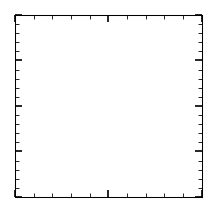

In [18]:
#make plot
if which_sne_data == 'lsst_binned':
    sne_exp_lab = 'LSST'
elif which_sne_data == 'lsst_unbinned':
    sne_exp_lab = 'LSST-unbinned'
elif which_sne_data == 'des':
    sne_exp_lab = 'DES'
#desired_params_to_plot = ['h', 'omch2', 'ws', 'wa']
desired_params_to_plot = sne_params
zlabel_dic = {}
for ziter in sne_z_bin_dic:
    zlabel_dic[ziter] = r'%s SNe: $%g \le z < %g$' %(sne_exp_lab, sne_z_bin_dic[ziter][0], sne_z_bin_dic[ziter][1])
    '''
    if maxz_dic[ziter] > 1.5:
        zlabel_dic[maxz_iter] = r'%s SNe: All' %(sne_exp_lab)
    '''
print(zlabel_dic)
color_dic = {0: 'navy', 1: 'darkgreen', 2: 'goldenrod', 3: 'orangered', 4: 'black'}
         
fix_axis_range_to_xxsigma = 3 ##3 ##10 ##None #3
fsval = 12

reqd_sne_cov_tag = 0 ##8 ##0 ##8
clf()
tr, tc = len( desired_params_to_plot ), len( desired_params_to_plot )
figure(figsize = (tr+4, tc+4))
subplots_adjust(hspace=0.15, wspace = 0.15)
for curr_sne_cov_tag in sne_cov_tag_dic:
    if curr_sne_cov_tag != reqd_sne_cov_tag: continue
    parent_fisher_dic = {}
    for ztag in master_fisher_dic[curr_sne_cov_tag]:
        curr_f_mat = master_fisher_dic[curr_sne_cov_tag][ztag][0]
        ##print(curr_f_mat); sys.exit()
        parent_fisher_dic[ztag] = curr_f_mat
    ##print(parent_fisher_dic.keys()); sys.exit()
    ##color_dic = {0: 'black'}
    ##print( parent_fisher_dic )
    color_dic, ls_dic = misc.make_triangle_plot(parent_fisher_dic, tr, tc, sne_params, param_dict, desired_params_to_plot, fsval = fsval, color_dic = color_dic, fix_axis_range_to_xxsigma = fix_axis_range_to_xxsigma)#, one_or_two_sigma = 1, fsval = 12, noofticks = 4)

#legend
if len(desired_params_to_plot)>=3:
    ax = subplot(tr, tc, 3)
elif len(desired_params_to_plot)==2:
    ax = subplot(tr, tc, 2)
else:
    ax = subplot(tr, tc, 1)
for ziter in zlabel_dic:
    plot([], [], color = color_dic[ziter], label = r'%s' %(zlabel_dic[ziter]))

legend(loc = 2, fontsize = fsval, framealpha = 0., title = r'{\bf Errors: %s}' %(sne_cov_tag_dic[reqd_sne_cov_tag]))
axis('off')

'''
#save thr Fisher matrix
opfname = 'data/lsst_SNe/fisher_sne_tmp.npy'
op_dic = {}
op_dic['fisher'] = master_fisher_dic
op_dic['param_dict'] = param_dict
op_dic['params'] = params
print(params)
np.save( opfname, op_dic )
'''

# Transformed fisher for omega_m

In [43]:
if transform_fisher:
    fix_params_arr = ['h', 'M']
    mod_param_arr = [['omch2', 'omega_m']]
    param_dict['omega_m'] = param_dict['omch2'] / param_dict['h']**2.
    desired_params_to_plot = ['omega_m', 'ws', 'wa']


    reqd_sne_cov_tag = 0 ##8 ##0 ##8
    clf()
    tr, tc = len( desired_params_to_plot ), len( desired_params_to_plot )
    figure(figsize = (tr+4, tc+4))
    subplots_adjust(hspace=0.15, wspace = 0.15)
    for curr_sne_cov_tag in sne_cov_tag_dic:
        if curr_sne_cov_tag != reqd_sne_cov_tag: continue
        print(curr_sne_cov_tag)
        parent_fisher_dic = master_fisher_dic[curr_sne_cov_tag]

        #rotate Fisher matrix now
        parent_fisher_dic_mod, param_names_mod = misc.rotate_fisher_mat_parent(parent_fisher_dic, sne_params, param_dict, mod_param_arr, fix_params_arr = fix_params_arr)
        ###sys.exit()

        color_dic, ls_dic = misc.make_triangle_plot(parent_fisher_dic_mod, tr, tc, param_names_mod, param_dict, desired_params_to_plot, fsval = fsval, color_dic = color_dic, fix_axis_range_to_xxsigma = fix_axis_range_to_xxsigma)#, one_or_two_sigma = 1, fsval = 12, noofticks = 4)

    #legend
    if len(desired_params_to_plot)>=3:
        ax = subplot(tr, tc, 3)
    elif len(desired_params_to_plot)==2:
        ax = subplot(tr, tc, 2)
    else:
        ax = subplot(tr, tc, 1)
    for liter in zlabel_dic:
        print(liter)
        plot([], [], color = color_dic[liter], label = r'%s' %(zlabel_dic[liter]))

    legend(loc = 2, fontsize = fsval, framealpha = 0., title = r'{\bf Errors: %s}' %(sne_cov_tag_dic[reqd_sne_cov_tag]))
    axis('off')

# Fisher bias

Reading and process details for which_sne_data = lsst_binned
	Cov inv file = data/lsst_SNe//sne_lsst_binned_cov_inv.npy. Exists = True
		getting the covariance and cov inv for tag = 0 (Stat + sys-All)
		getting the covariance and cov inv for tag = 1 (Stat-only)
		getting the covariance and cov inv for tag = 2 (Stat + sys-ZSHIFT)
		getting the covariance and cov inv for tag = 3 (Stat + sys-ZERRSCALE)
		getting the covariance and cov inv for tag = 4 (Stat + sys-Photo_shift)
		getting the covariance and cov inv for tag = 5 (Stat + sys-MWEBV)
		getting the covariance and cov inv for tag = 6 (Stat + sys-Cal_ZP)
		getting the covariance and cov inv for tag = 7 (Stat + sys-Cal_wave)
		getting the covariance and cov inv for tag = 8 (Stat + sys-Cal)
SNe cov tag = 0
omch2 0.12 0.12
ws -1 -1.0
wa 0 0.0
M -19.5 -19.5
omch2 0.12 0.07529284969447303
ws -1 -0.894958547898284
wa 0 0.859552094531864
M -19.5 -19.49677290271214


<Figure size 900x600 with 0 Axes>

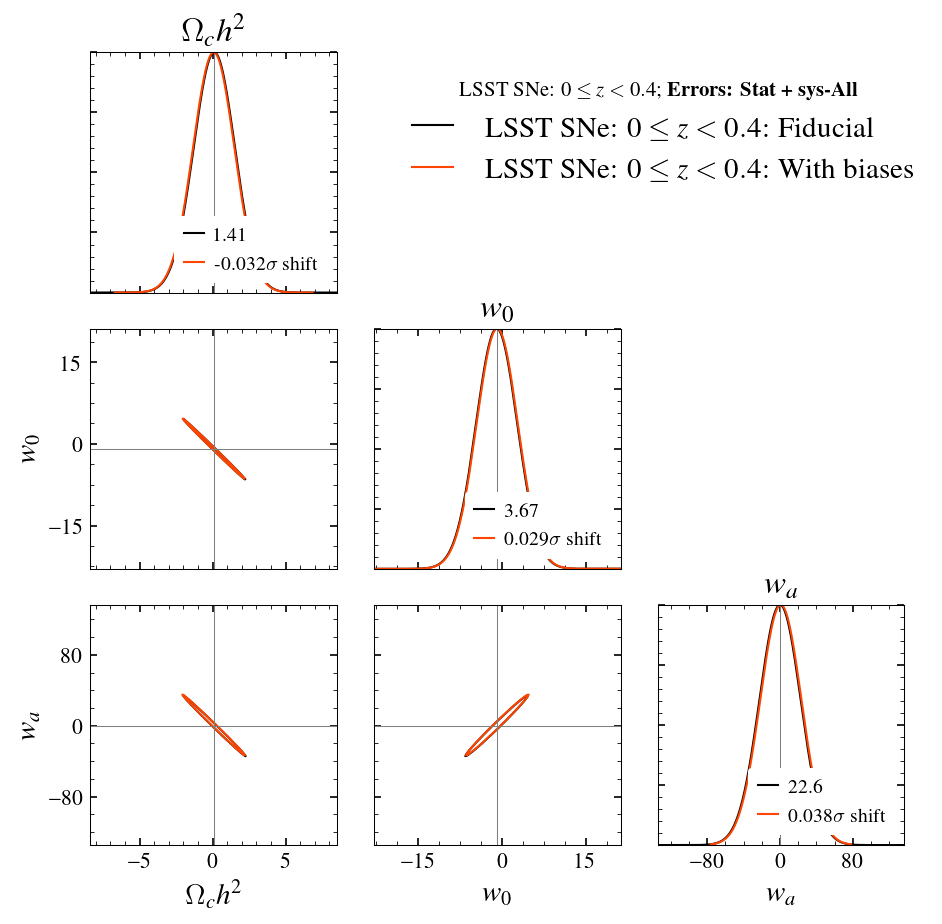

SNe cov tag = 1
SNe cov tag = 2
SNe cov tag = 3
SNe cov tag = 4
SNe cov tag = 5
SNe cov tag = 6
SNe cov tag = 7
SNe cov tag = 8


In [126]:
import copy
if (0): #plot sys errors
    plot(sne_zarr, sne_muarr, 'r.')
    plot(sne_zarr, sne_muarr - sne_muerr_sys, 'k.'); show()
    sys.exit()

reqd_sne_cov_tag = 0 ##8 ##0
reqd_ziter = 0 ##1 #3
if which_sne_data == 'des':
    reqd_sne_cov_tag = 0
    reqd_ziter = 0
    
sne_details_dic = sne_cmb_fisher_tools.get_sne_details(which_sne_data, unbinned_sne_sim_no = unbinned_sne_sim_no, obtain_covs = True)
sne_zarr = sne_details_dic['sne_zarr']
sne_muarr = sne_details_dic['sne_muarr']
sne_muerr_stat = sne_details_dic['sne_muerr_stat']
sne_muerr_sys = sne_details_dic['sne_muerr_sys']
sne_muerr_stat = sne_details_dic['sne_muerr_stat']
sne_stretch_x1_arr = sne_details_dic['sne_stretch_x1']
sne_color_c_arr = sne_details_dic['sne_color_c']
sne_z_bin_dic = sne_details_dic['sne_z_bin_dic']
sne_params = sne_details_dic['sne_params']
sne_sys_cov_dic = sne_details_dic['sne_sys_cov_dic']
sne_stat_cov = sne_details_dic['sne_stat_cov']
sne_tot_cov_dic = sne_details_dic['sne_tot_cov_dic']
sne_tot_cov_inv_dic = sne_details_dic['sne_tot_cov_inv_dic']
sne_cov_tag_dic = sne_details_dic['sne_cov_tag_dic']

master_fisher_bias_dic = {}
for curr_sne_cov_tag in sne_cov_tag_dic:
    print('SNe cov tag = %s' %(curr_sne_cov_tag))

    master_fisher_bias_dic[curr_sne_cov_tag] = {}
    for ziter in range(len(sne_z_bin_dic)):
        
        #perform selection for the current z-bin
        zinds = np.where( (sne_zarr>sne_z_bin_dic[ziter][0]) & (sne_zarr<=sne_z_bin_dic[ziter][1]) )[0]
        curr_sne_zarr = sne_zarr[zinds]
        curr_sne_muarr = sne_muarr[zinds]        
        
        ##curr_sne_muerr_sys = sne_muerr_sys[zinds]
        curr_sne_sys_cov = sne_sys_cov_dic[curr_sne_cov_tag][zinds[:, None], zinds[None, :]]
        curr_sne_muerr_sys = np.diag(curr_sne_sys_cov)**0.5

        curr_sne_cov, curr_sne_cov_inv = None, None
        curr_sne_stat_cov = sne_stat_cov[zinds[:, None], zinds[None, :]]
        if sne_tot_cov_dic is not None:
            curr_sne_cov = np.copy(sne_tot_cov_dic[curr_sne_cov_tag])
            curr_sne_cov = curr_sne_cov[zinds[:, None], zinds[None, :]]
        if sne_tot_cov_inv_dic is not None:
            curr_sne_cov_inv = np.copy(sne_tot_cov_inv_dic[curr_sne_cov_tag])
            curr_sne_cov_inv = curr_sne_cov_inv[zinds[:, None], zinds[None, :]]

            
        #get distance modules derivatives w.r.t cosmo params
        if 'omch2' in sne_params:
            use_hsq_units = True
        elif 'omega_m' in sne_params:
            use_hsq_units = False
        distance_modulus_deriv_dict = sne_cmb_fisher_tools.get_distance_modulus_derivatives(curr_sne_zarr, param_dict, sne_params, baselinecosmo = baselinecosmo, use_hsq_units = use_hsq_units)

        #get Fisher
        lsst_dm_sne_fisher_mat = sne_cmb_fisher_tools.get_sne_distance_modulus_fisher(sne_params, curr_sne_cov, curr_sne_zarr, distance_modulus_deriv_dict, cov_inv = curr_sne_cov_inv)
    
        #get Fisher bias
        #final_bias_vector = sne_cmb_fisher_tools.get_bias_vector(lsst_dm_sne_fisher_mat, sne_params, curr_sne_zarr, curr_sne_stat_cov, curr_sne_muarr, curr_sne_muerr_sys, distance_modulus_deriv_dict)
        final_bias_vector = sne_cmb_fisher_tools.get_bias_vector(lsst_dm_sne_fisher_mat, sne_params, curr_sne_zarr, curr_sne_cov, curr_sne_muarr, curr_sne_muerr_sys, distance_modulus_deriv_dict, cov_inv = curr_sne_cov_inv)
        ###print( final_bias_vector )
        ##print( final_bias_vector ); sys.exit()
        master_fisher_bias_dic[curr_sne_cov_tag][ziter] = [sne_params, lsst_dm_sne_fisher_mat, final_bias_vector]
        

        if curr_sne_cov_tag == reqd_sne_cov_tag and ziter == reqd_ziter: #show plot
            clf()
            tr, tc = len( desired_params_to_plot ), len( desired_params_to_plot )
            figure(figsize = (tr+4, tc+4))
            subplots_adjust(hspace=0.15, wspace = 0.15)
            color_arr = ['black', 'orangered']
            zlabelval = r'%s SNe: $%g \le z < %g$' %(sne_exp_lab, sne_z_bin_dic[ziter][0], sne_z_bin_dic[ziter][1])
            itername_arr = [r'%s: Fiducial' %(zlabelval), r'%s: With biases' %(zlabelval)]
            sne_exp_lab = r'LSST'

            for pliter in range(2): 
                bias_dic = None
                param_dict_mod = copy.deepcopy( param_dict )
                if pliter == 0:
                    itername = itername_arr[pliter]
                    curr_final_bias_vector = np.zeros_like(final_bias_vector)        
                else:
                    itername = itername_arr[pliter]
                    curr_final_bias_vector = np.copy(final_bias_vector)

                ##print(curr_final_bias_vector); sys.exit()
                for pind, p in enumerate( sne_params ):
                    fid_val = param_dict_mod[p]
                    mod_val = fid_val + curr_final_bias_vector[pind]
                    print(p, fid_val, mod_val)
                    param_dict_mod[p] = mod_val
                ##sys.exit()

                if pliter == 1:
                    bias_dic = {}
                    for pind, p in enumerate( sne_params ):
                        shifted_val = param_dict[p] - curr_final_bias_vector[pind]
                        bias_dic[p] = [shifted_val, curr_final_bias_vector[pind]]


                F_dic = {}
                F_dic[itername] = lsst_dm_sne_fisher_mat

                color_dic = {}
                color_dic[itername] = color_arr[pliter]

                fix_axis_range_to_xxsigma = 6.
                if pliter == 0:
                    mark_fid_lines = True
                else:
                    mark_fid_lines = False
                color_dic, ls_dic = misc.make_triangle_plot(F_dic, tr, tc, sne_params, param_dict_mod, desired_params_to_plot, fsval = fsval, color_dic = color_dic, fix_axis_range_to_xxsigma = fix_axis_range_to_xxsigma, bias_dic = bias_dic, ncol = 1, mark_fid_lines = mark_fid_lines)#, one_or_two_sigma = 1, fsval = 12, noofticks = 4)

            #legend
            if len(desired_params_to_plot)>3:
                ax = subplot(tr, tc, 2)
            elif len(desired_params_to_plot)==3:
                ax = subplot(tr, tc, 2)
            elif len(desired_params_to_plot)==2:
                ax = subplot(tr, tc, 2)
            else:
                ax = subplot(tr, tc, 1)

            for pliter in range(2):
                plot([], [], color = color_arr[pliter], label = r'%s' %(itername_arr[pliter]))

            legend(loc = 2, fontsize = fsval, framealpha = 0., title = r'%s; {\bf Errors: %s}' %(zlabelval, sne_cov_tag_dic[reqd_sne_cov_tag]))
            axis('off')            
            show(); ##sys.exit()


In [119]:
final_bias_vector

array([-0.01273409,  0.03480327,  0.28421737,  0.006388  ])

omch2 -0.1482429018331618 -0.19295005213868877
ws -0.369751287389704 -0.26470983528798797
wa 5.157312567191184 6.016864661723048
M -19.48063741627285 -19.47741031898499
omch2 1 0.4015
ws 1 0.7799
wa 1 0.30800000000000005


<Figure size 900x600 with 0 Axes>

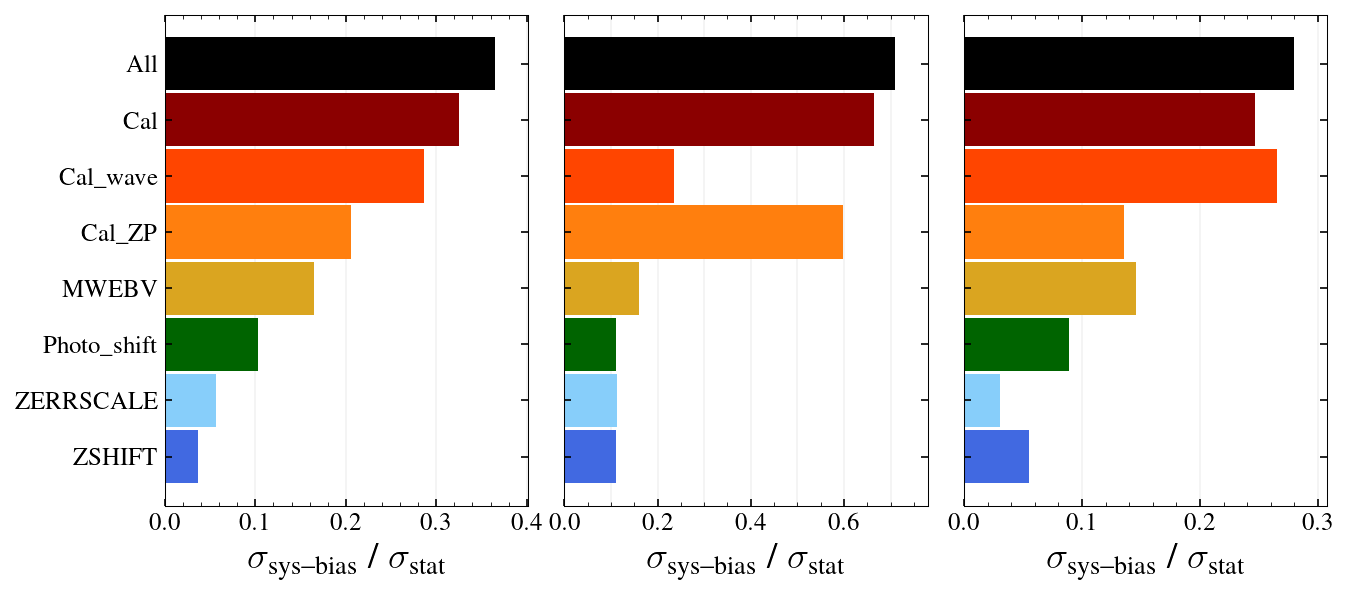

SystemExit: 

In [132]:
ind_params_for_bar_plot = ['omch2', 'ws', 'wa']
fix_params_arr_for_ind_params = None

reqd_z_bin = 3

bias_dic_to_plot = {}
for curr_sne_cov_tag in master_fisher_bias_dic:
    bias_dic_to_plot[curr_sne_cov_tag] = {}
    for curr_ziter in master_fisher_bias_dic[curr_cov_tag]:
        curr_params, curr_F_mat, curr_bias_vector = master_fisher_bias_dic[curr_sne_cov_tag][reqd_z_bin]
        curr_sigma_dic = misc.get_sigma_of_a_parameter(curr_F_mat, curr_params, ind_params_for_sigma_calc, fix_params_arr = fix_params_arr_for_ind_params)
        curr_bias_dic = {}
        for (p, b) in zip( curr_params, curr_bias_vector):
            curr_bias_dic[p] = b
        bias_dic_to_plot[curr_sne_cov_tag][curr_ziter] = [curr_sigma_dic, curr_bias_dic]

    ##print( curr_sne_cov_tag, curr_bias_dic )
##sys.exit()

for pind, p in enumerate( sne_params ):
    fid_val = param_dict_mod[p]
    mod_val = fid_val + curr_final_bias_vector[pind]
    print(p, fid_val, mod_val)
    param_dict_mod[p] = mod_val

clf()
fsval = 14
rspan_1, rspan_2, rspan_gap = 2, 8, 1
tr, tc = rspan_1+rspan_2+rspan_gap, len( ind_params_for_bar_plot )
figure(figsize = (10, 6.))
subplots_adjust(wspace = 0.1, hspace = 0.25)
for pcntr, ppp in enumerate( ind_params_for_bar_plot ):

    ax = subplot2grid((tr, tc), (rowval, pcntr), rowspan = rspan)
    color_dict = {0: 'black', 1: 'tab:green', 2: 'royalblue', 3: 'lightskyblue', 
                  4: 'darkgreen', 5: 'goldenrod', 
                 6: 'tab:orange', 7: 'orangered', 8: 'darkred'}

    #fiducial
    fid_sne_cov_tag = 1 #stat-only
    fid_sigma_val = bias_dic_to_plot[fid_sne_cov_tag][reqd_z_bin][0][ppp]
    fid_param_val = param_dict_mod[ppp]

    #reqd_sne_cov_tag = list( sigma_dic.keys() )
    reqd_sne_cov_tag = [2,3,4,5,6,7,8,0]
    #reqd_sne_cov_tag.remove( fid_sne_cov_tag )

    #plot sigma for different cov cases
    xmaxval = 0.
    ytick_label_arr = []
    yloc = 0
    #reqd_sne_cov_tag = list( bias_dic_to_plot.keys() )
    for cntr, curr_sne_cov_tag in enumerate( reqd_sne_cov_tag ):
        if curr_sne_cov_tag not in reqd_sne_cov_tag: continue
        if curr_sne_cov_tag == 1: continue #remove no-sys
                
        curr_sigma_val = bias_dic_to_plot[curr_sne_cov_tag][reqd_z_bin][0][ppp]
        curr_bias_val = bias_dic_to_plot[curr_sne_cov_tag][reqd_z_bin][1][ppp]
        ##print( ppp, curr_sne_cov_tag, curr_bias_val )
        #curr_param_val = param_dict_mod[ppp]


        curr_val = abs(curr_bias_val / fid_sigma_val)
        ##curr_val = abs(curr_bias_val / curr_sigma_val)
        barh( yloc, curr_val, height = 0.95, color = color_dict[curr_sne_cov_tag])
        if (0):##pliter == 0: 
            text(
                0., yloc*0.9, '%g' %(curr_val),
                va='center',
                ha='left',  # Left-align the text
                fontsize=fsval-2,  # Using the given fontsize for bar text
                color='black',  # White color makes the text more readable on colored bars                    
                bbox=dict(edgecolor = 'None', facecolor='white', boxstyle='round,pad=0.1')
            )
        xmaxval = max( xmaxval, curr_val )
        tmpsplit = sne_cov_tag_dic[curr_sne_cov_tag].split('+')
        if len(tmpsplit) == 1:
            curr_ylab = r'No sys'
        else:
            curr_ylab = tmpsplit[1].replace('_', '\_').replace('sys-', '')
        ytick_label_arr.append( curr_ylab )
        yloc += 1

    xmaxval = round(xmaxval, 3) * 1.1
    print(ppp, pliter, xmaxval)
    xlim(0., xmaxval)
    
    if (1): #draw grids
        ##grid(True, which = 'major', axis = 'x', lw = 0.2, zorder = -100, alpha = 0.2)
        tmpxarr_for_gridlines = np.arange( 0., xmaxval, 0.1)
        for gl in tmpxarr_for_gridlines:
            axvline( gl, lw = 0.2, zorder = -100., alpha = 0.2)
        
    
    ax = misc.format_axis(ax, fsval-2, fsval-2)

    if pliter == 0:
        title(r'%s' %(misc.get_latex_param_str(ppp)), fontsize = fsval + 6)
    
    #ax.set_yticklabels(ytick_label_arr)
    yticks(np.arange(len(ytick_label_arr)), ytick_label_arr)
    #ax.yaxis.set_major_locator(plt.MaxNLocator(len(ytick_label_arr)))
    if pcntr != 0:
        setp(ax.get_yticklabels(), visible=False)
    ax.tick_params(axis='y', which='minor', length=0)
    xlabel(r'$\sigma_{\rm sys-bias}$ / $\sigma_{\rm stat}$', fontsize = fsval + 4)
    ##axvspan(0., 1, alpha = 0.3, color = 'gray', zorder = -100)

#plname = 'plots/sne_constraints_stat_plus_sys.pdf'
#savefig( plname, dpi = 200.)
show(); sys.exit()
        
    
      

In [92]:
sne_cov_tag_dic[curr_sne_cov_tag]

'Stat-only'

(4, 4)
(4, 4)
(3, 3)
dict_keys([0, 1, 2])
0
1
2


<Figure size 900x600 with 0 Axes>

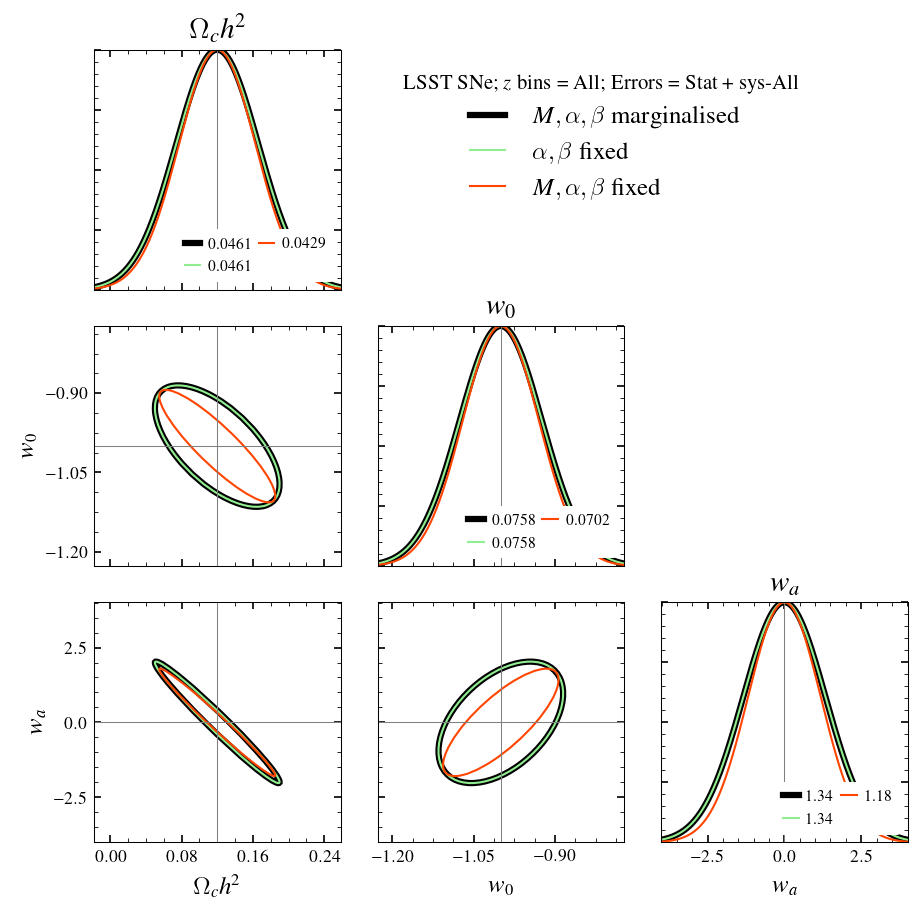

In [46]:
# Fixed vs marginalised M

sne_exp_lab = 'LSST'
zlabval = r'%s SNe; $z$ bins = All' %(sne_exp_lab)
color_dic = {0: 'black', 1: 'lightgreen', 2: 'orangered'}
lw_dic = {0: 3., 1: 1., 2: 1.}
labval_dic = {0: r'$M, \alpha, \beta$ marginalised', 1: r'$\alpha, \beta$ fixed', 2: r'$M, \alpha, \beta$ fixed'}
fix_axis_range_to_xxsigma = 3 ##10 ##None #3
fsval = 12
reqd_sne_cov_tag = 0 ##8 ##0 ##8
reqd_z_iter = 3
fisher_dic_to_plot = {}
for tmpiter in range(3):

    desired_params_to_plot = ['omch2', 'ws', 'wa']
    curr_F_mat = np.copy( master_fisher_dic[reqd_sne_cov_tag][reqd_z_iter] )
    
    if tmpiter == 1:
        curr_F_mat, curr_mod_params = misc.fix_params(np.copy(curr_F_mat), np.copy(sne_params), ['alpha', 'beta'])
    elif tmpiter == 2:
        curr_F_mat, curr_mod_params = misc.fix_params(np.copy(curr_F_mat), np.copy(sne_params), ['M', 'alpha', 'beta'])
    print(curr_F_mat.shape)
    
    fisher_dic_to_plot[tmpiter] = curr_F_mat
    
print( fisher_dic_to_plot.keys() )
           

clf()
tr, tc = len( desired_params_to_plot ), len( desired_params_to_plot )
figure(figsize = (tr+4, tc+4))
subplots_adjust(hspace=0.15, wspace = 0.15)
color_dic, ls_dic = misc.make_triangle_plot(fisher_dic_to_plot, tr, tc, sne_params, param_dict, desired_params_to_plot, fsval = fsval, color_dic = color_dic, fix_axis_range_to_xxsigma = fix_axis_range_to_xxsigma, lw_dic = lw_dic)#, one_or_two_sigma = 1, fsval = 12, noofticks = 4)

#legend
ax = subplot(tr, tc, 2)
for liter in labval_dic:
    print(liter)
    plot([], [], color = color_dic[liter], label = r'%s' %(labval_dic[liter]), lw = lw_dic[liter])

legend(loc = 2, fontsize = fsval, framealpha = 0., title = r'%s; Errors = %s' %(zlabval, sne_cov_tag_dic[reqd_sne_cov_tag]))
axis('off')
show()

# Whisker plots for individual parameters

omch2 0 0.050600000000000006
ws 0 0.08360000000000001
wa 0 1.4718000000000002
M 0 0.0121
omch2 1 1.2958
ws 1 1.5939
wa 1 1.2793
M 1 1.3475000000000001


<Figure size 900x600 with 0 Axes>

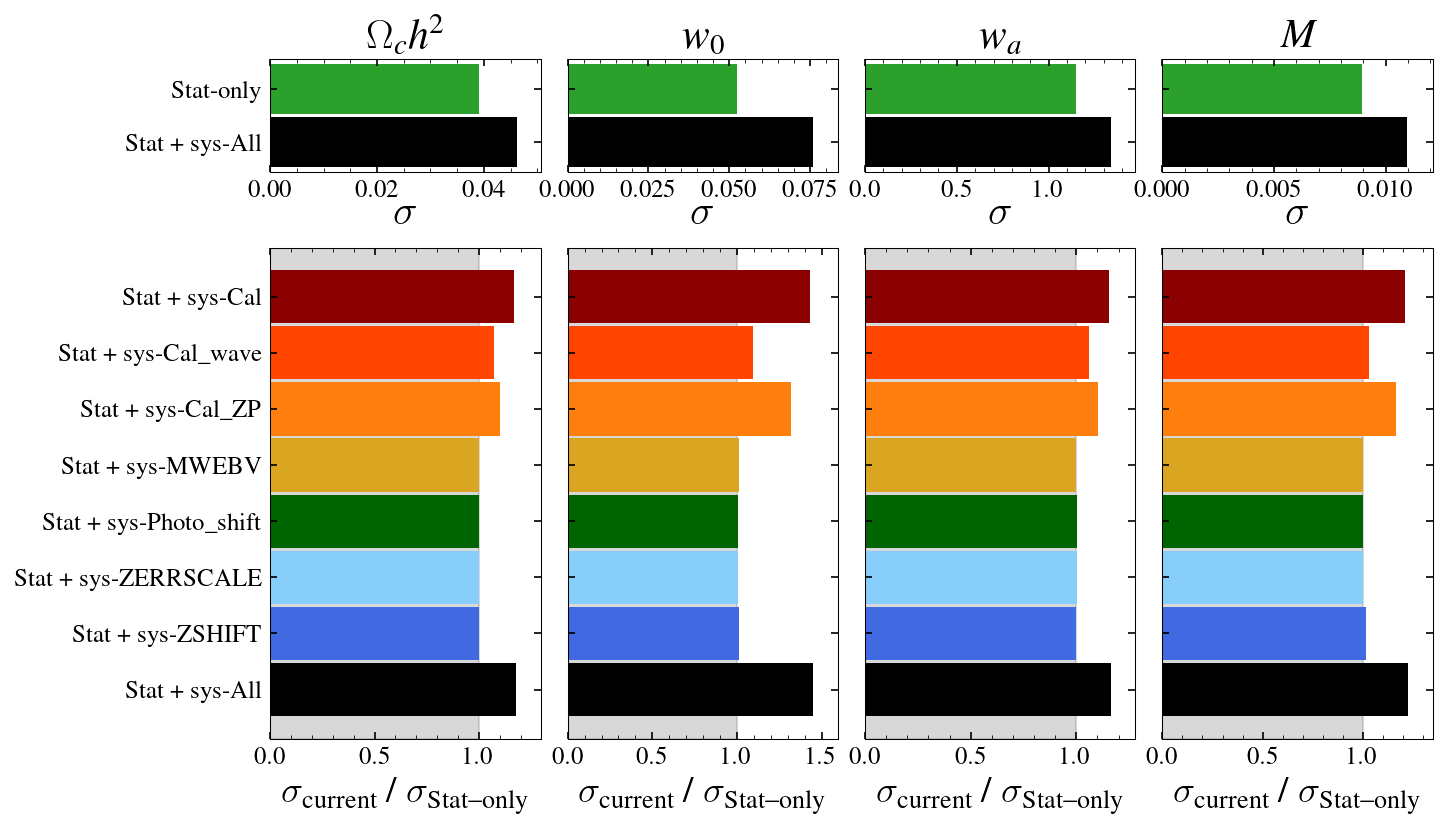

SystemExit: 

In [48]:
reqd_z_bin = 3
if (0):
    ind_params_for_sigma_calc = ['omch2', 'ws', 'wa'] ###np.copy(sne_params)
    fix_params_arr_for_ind_params = ['M']
if (1):
    ind_params_for_sigma_calc = np.copy(sne_params)
    fix_params_arr_for_ind_params = None

sigma_dic = {}
for curr_sne_cov_tag in sne_cov_tag_dic:
    curr_F_mat = master_fisher_dic[curr_sne_cov_tag][reqd_z_bin]
    curr_sigma_dic = misc.get_sigma_of_a_parameter(curr_F_mat, sne_params, ind_params_for_sigma_calc, fix_params_arr = fix_params_arr_for_ind_params)
    ###print( curr_sne_cov_tag, curr_sigma_dic )
    sigma_dic[curr_sne_cov_tag] = curr_sigma_dic

    
clf()
fsval = 14
rspan_1, rspan_2, rspan_gap = 2, 8, 1
tr, tc = rspan_1+rspan_2+rspan_gap, len( ind_params_for_sigma_calc )
figure(figsize = (10, 6.))
subplots_adjust(wspace = 0.1, hspace = 0.25)
for pliter in range(2):

    if pliter == 0:
        rspan = rspan_1
        rowval = 0
    else:
        rspan = rspan_2
        rowval = rspan_1+rspan_gap
    
    for pcntr, ppp in enumerate( ind_params_for_sigma_calc ):


        ax = subplot2grid((tr, tc), (rowval, pcntr), rowspan = rspan)
        color_dict = {0: 'black', 1: 'tab:green', 2: 'royalblue', 3: 'lightskyblue', 
                      4: 'darkgreen', 5: 'goldenrod', 
                     6: 'tab:orange', 7: 'orangered', 8: 'darkred'}

        if pliter == 0:
            reqd_sne_cov_tag = [0, 1]
        else:
            fid_sne_cov_tag = 1 #stat-only
            fid_sigma_val = sigma_dic[fid_sne_cov_tag][ppp]
            reqd_sne_cov_tag = list( sigma_dic.keys() )
            reqd_sne_cov_tag.remove( fid_sne_cov_tag )
            #reqd_sne_cov_tag = [1, 8, 6, 7, 5, 4, 3, 2]

        #plot sigma for different cov cases
        xmaxval = 0.
        ytick_label_arr = []
        yloc = 0
        for cntr, curr_sne_cov_tag in enumerate( reqd_sne_cov_tag ):
            if curr_sne_cov_tag not in reqd_sne_cov_tag: continue
                    
            curr_sigma_val = sigma_dic[curr_sne_cov_tag][ppp]
            if pliter == 0:
                curr_val = curr_sigma_val                
            else:
                curr_val = curr_sigma_val / fid_sigma_val
                ##print( curr_val ); sys.exit()
            barh( yloc, curr_val, height = 0.95, color = color_dict[curr_sne_cov_tag])
            if (0):##pliter == 0: 
                text(
                    0., yloc*0.9, '%g' %(curr_val),
                    va='center',
                    ha='left',  # Left-align the text
                    fontsize=fsval-2,  # Using the given fontsize for bar text
                    color='black',  # White color makes the text more readable on colored bars                    
                    bbox=dict(edgecolor = 'None', facecolor='white', boxstyle='round,pad=0.1')
                )
            xmaxval = max( xmaxval, curr_val )
            ytick_label_arr.append( sne_cov_tag_dic[curr_sne_cov_tag].replace('_', '\_') )
            yloc += 1

        xmaxval = round(xmaxval, 3) * 1.1
        print(ppp, pliter, xmaxval)
        xlim(0., xmaxval)
        
        ax = misc.format_axis(ax, fsval-2, fsval-2)

        if pliter == 0:
            title(r'%s' %(misc.get_latex_param_str(ppp)), fontsize = fsval + 6)
        
        #ax.set_yticklabels(ytick_label_arr)
        yticks(np.arange(len(ytick_label_arr)), ytick_label_arr)
        #ax.yaxis.set_major_locator(plt.MaxNLocator(len(ytick_label_arr)))
        if pcntr != 0:
            setp(ax.get_yticklabels(), visible=False)
        ax.tick_params(axis='y', which='minor', length=0)
        if pliter == 0:
            #xlabel(r'$\sigma$(%s)' %(misc.get_latex_param_str(ppp)), fontsize = fsval + 4)
            xlabel(r'$\sigma$', fontsize = fsval + 6, labelpad = -3)
        else:
            xlabel(r'$\sigma_{\rm current}$ / $\sigma_{\rm Stat-only}$', fontsize = fsval + 4)
            axvspan(0., 1, alpha = 0.3, color = 'gray', zorder = -100)
    
#plname = 'plots/sne_constraints_stat_plus_sys.pdf'
#savefig( plname, dpi = 200.)
show(); sys.exit()
        
    
    

# Transformed fisher for DES

In [45]:
if (1):##perform_checks_with_des:
    fix_params_arr = ['h']
    mod_param_arr = [['omch2', 'omega_m']]
    param_dict['omega_m'] = param_dict['omch2'] / param_dict['h']**2.
    desired_params_to_plot = ['omega_m', 'ws']#, 'wa']


    reqd_sne_cov_tag = 0 ##8 ##0 ##8
    clf()
    tr, tc = len( desired_params_to_plot ), len( desired_params_to_plot )
    figure(figsize = (tr+4, tc+4))
    subplots_adjust(hspace=0.15, wspace = 0.15)
    for curr_sne_cov_tag in sne_cov_tag_dic:
        if curr_sne_cov_tag != reqd_sne_cov_tag: continue
        print(curr_sne_cov_tag)
        parent_fisher_dic = master_fisher_dic[curr_sne_cov_tag]

        #rotate Fisher matrix now
        parent_fisher_dic_mod, param_names_mod = misc.rotate_fisher_mat_parent(parent_fisher_dic, params, param_dict, mod_param_arr, fix_params_arr = fix_params_arr)
        ###sys.exit()

        color_dic, ls_dic = misc.make_triangle_plot(parent_fisher_dic_mod, tr, tc, param_names_mod, param_dict, desired_params_to_plot, fsval = fsval, color_dic = color_dic, fix_axis_range_to_xxsigma = fix_axis_range_to_xxsigma)#, one_or_two_sigma = 1, fsval = 12, noofticks = 4)

    #legend
    if len(desired_params_to_plot)>=3:
        ax = subplot(tr, tc, 3)
    elif len(desired_params_to_plot)==2:
        ax = subplot(tr, tc, 2)
    else:
        ax = subplot(tr, tc, 1)
    for liter in zlabel_dic:
        print(liter)
        plot([], [], color = color_dic[liter], label = r'%s' %(zlabel_dic[liter]))

    legend(loc = 2, fontsize = fsval, framealpha = 0., title = r'{\bf Errors: %s}' %(sne_cov_tag_dic[reqd_sne_cov_tag]))
    axis('off')

0


KeyError: 0

<Figure size 900x600 with 0 Axes>

<Figure size 900x900 with 0 Axes>

omch2 0 0.0473
ws 0 0.07700000000000001
wa 0 1.3013000000000001
omch2 1 1.6335000000000002
ws 1 1.4839
wa 1 1.7039


<Figure size 900x600 with 0 Axes>

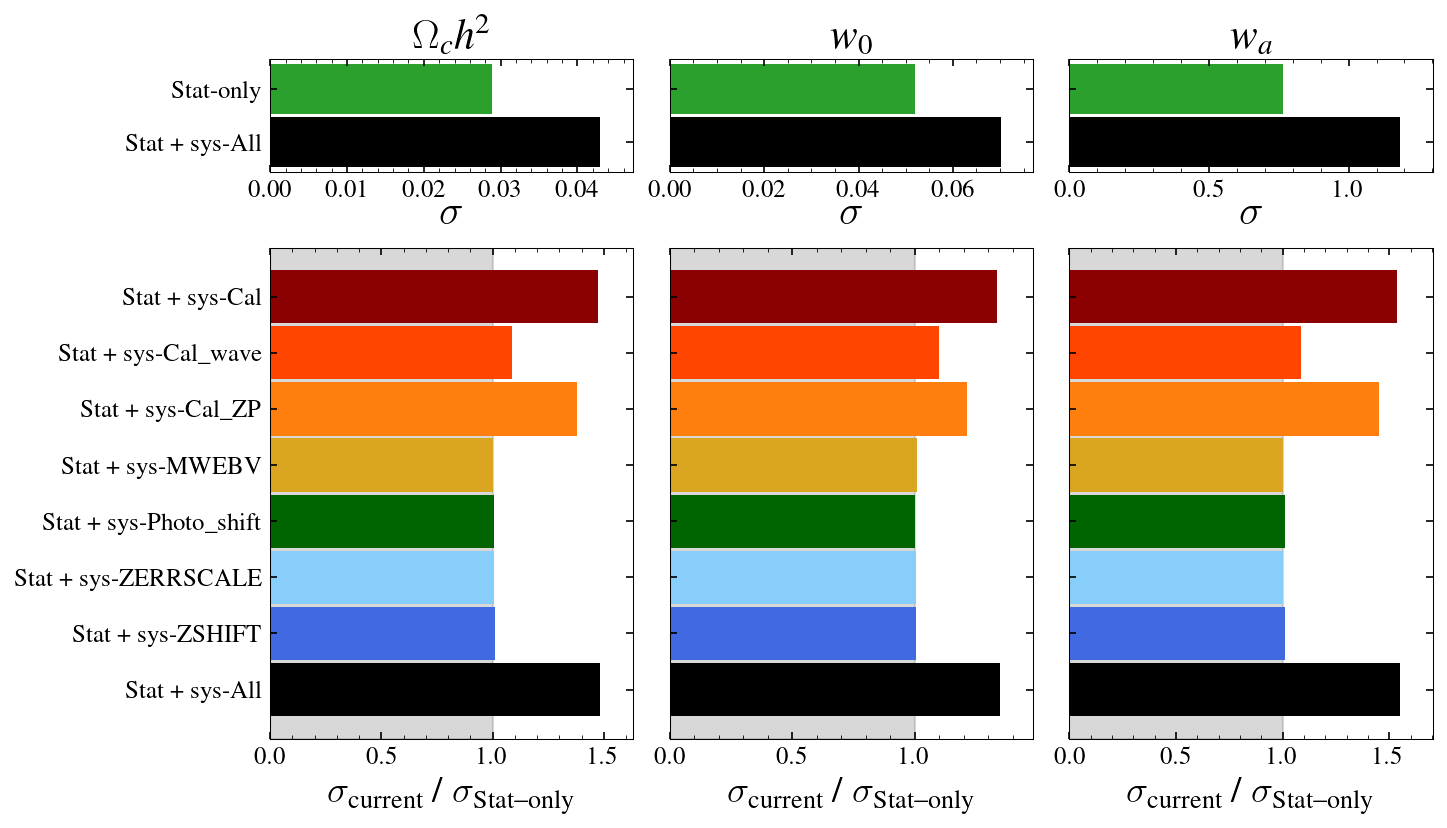

SystemExit: 

/usr/local/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3449: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [45]:
ax.set_yticklabels

In [105]:
'''
#make plot
desired_params_to_plot = ['h', 'omch2', 'w0', 'wa']
fisher_dic = {'LSST': lsst_dm_sne_fisher_mat}
color_dic = {'LSST': 'black'}
fix_axis_range_to_xxsigma = 3
fsval = 12

clf()
tr, tc = len( desired_params_to_plot ), len( desired_params_to_plot )
figure(figsize = (tr+4, tc+4))
subplots_adjust(hspace=0.15, wspace = 0.15)
color_dic, ls_dic = misc.make_triangle_plot(fisher_dic, tr, tc, params, param_dict, desired_params_to_plot, fsval = fsval, color_dic = color_dic, fix_axis_range_to_xxsigma = fix_axis_range_to_xxsigma)#, one_or_two_sigma = 1, fsval = 12, noofticks = 4)
'''

"\n#make plot\ndesired_params_to_plot = ['h', 'omch2', 'w0', 'wa']\nfisher_dic = {'LSST': lsst_dm_sne_fisher_mat}\ncolor_dic = {'LSST': 'black'}\nfix_axis_range_to_xxsigma = 3\nfsval = 12\n\nclf()\ntr, tc = len( desired_params_to_plot ), len( desired_params_to_plot )\nfigure(figsize = (tr+4, tc+4))\nsubplots_adjust(hspace=0.15, wspace = 0.15)\ncolor_dic, ls_dic = misc.make_triangle_plot(fisher_dic, tr, tc, params, param_dict, desired_params_to_plot, fsval = fsval, color_dic = color_dic, fix_axis_range_to_xxsigma = fix_axis_range_to_xxsigma)#, one_or_two_sigma = 1, fsval = 12, noofticks = 4)\n"

In [ ]:
if (0): #external CMB fisher
    sobaseline_fisher_fname = 'data/cmb_fisher/SO/sobaseline_ilc_cmb_27-39-93-145-225-280_TT-EE_fsky-1_-1years_0.4fsky_300minlt_3500maxlt_300minlp_4000maxlp_TT-EE-TE-PP_MVlensingest_galaxy0_galmask-1_pluslensing_Alens-Aphiphi-As-h-mnu-neff-nrun-ns-ombh2-omch2-omk-tau-ws-13cosmo.npy'
    sogoal_fisher_fname = 'data/cmb_fisher/SO/sogoal_ilc_cmb_27-39-93-145-225-280_TT-EE_fsky-1_-1years_0.4fsky_300minlt_3500maxlt_300minlp_4000maxlp_TT-EE-TE-PP_MVlensingest_galaxy0_galmask-1_pluslensing_Alens-Aphiphi-As-h-mnu-neff-nrun-ns-ombh2-omch2-omk-tau-ws-13cosmo.npy'

    sobaseline_fisher_dic = np.load(sobaseline_fisher_fname, allow_pickle=True).item()
    sogoal_fisher_dic = np.load(sogoal_fisher_fname, allow_pickle=True).item()

    sobaseline_fisher_params = sobaseline_fisher_dic['param_names']
    sobaseline_fisher_F_mat = sobaseline_fisher_dic['F_mat']

    sogoal_fisher_params = sogoal_fisher_dic['param_names']
    sogoal_fisher_F_mat = sogoal_fisher_dic['F_mat']

    #fix params
    ##fix_param_arr = ['Alens', 'Aphiphi', 'mnu', 'neff', 'nrun', 'ns', 'ombh2', 'tau', 'As', 'omk']
    fix_param_arr = ['Alens', 'Aphiphi', 'mnu', 'neff', 'nrun', 'omk']
    sobaseline_fisher_F_mat, sobaseline_fisher_params = misc.fix_params(sobaseline_fisher_F_mat, sobaseline_fisher_params, fix_param_arr)
    sogoal_fisher_F_mat, sogoal_fisher_params = misc.fix_params(sogoal_fisher_F_mat, sogoal_fisher_params, fix_param_arr)
    
    print(sogoal_fisher_params); sys.exit()

    total_so_params = len(sogoal_fisher_params)
    
    #create a new Fisher matrix with wa. But wa will be zero for CMB
    sobaseline_fisher_F_mat_mod = np.zeros_like((total_so_params+1, total_so_params+1))
    sogoal_fisher_F_mat_mod = np.zeros_like((total_so_params+1, total_so_params+1))

    sobaseline_fisher_F_mat_mod[:3, :3] = sobaseline_fisher_F_mat
    sogoal_fisher_F_mat_mod[:3, :3] = sogoal_fisher_F_mat


    #joint: LSST + SO
    fisher_mat_sofull_lsstall = np.copy( parent_fisher_dic[maxz_key] ) + np.copy( sobaseline_fisher_F_mat_mod )

    parent_fisher_dic[maxz_key+1] = fisher_mat_sofull_lsstall


In [12]:
import astropy
from astropy import constants as const
from astropy import units as u
from astropy import coordinates as coord


cosmo = astropy.cosmology.Flatw0waCDM(H0 = param_dict['h']*100., 
                     Om0 = param_dict['omch2']/param_dict['h']**2., 
                     Ob0 = param_dict['ombh2']/param_dict['h']**2., 
                     Tcmb0 = param_dict['tcmb'], 
                     m_nu = [0., 0., param_dict['mnu']] * u.eV,
                     Neff = param_dict['neff'], 
                     w0 = param_dict['ws'], 
                     wa = param_dict['wa'], 
                     )


In [79]:
cosmo.Ode0

0.73401590965105

In [19]:
zval = 1.
5 * np.log10( cosmo.luminosity_distance(zval).value * 1e6 / 10 )

44.22881833789403

In [149]:
#param derivative and rotation stuff
params = ['As']
new_param_names = ['sigma_8']
#sne_cmb_fisher_tools.get_cosmo_derivatives_using_camb(params, new_param_names, param_dict)

camb_pars, camb_results = sne_cmb_fisher_tools.set_camb(param_dict, lmax = 1000)


In [150]:
camb_results.get_sigma8_0()


0.8105536759783709